In [1]:
print("Bienvenidos a la clase Cinco")

Bienvenidos a la clase Cinco


In [8]:
import pandas as pd

df = pd.DataFrame({
    "edad" : [20, 21, 39, 63, 45],
    "sueldo" : [1000, 2000, 3000, 4000, 5000],
})

df

,edad,sueldo
0,20,1000
1,21,2000
2,39,3000
3,63,4000
4,45,5000


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns = df.columns
)


df_scaled

,edad,sueldo
0,-0.508801,-1.414214
1,-0.508241,-0.707107
2,-0.498161,0.000000
3,-0.484721,0.707107
4,1.999924,1.414214


In [9]:
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler()

df_min_max_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns = df.columns
)

df_min_max_scaled

,edad,sueldo
0,0.000000,0.00
1,0.023256,0.25
2,0.441860,0.50
3,1.000000,0.75
4,0.581395,1.00


In [13]:
import pandas as pd

df = pd.DataFrame({
    "edad" : [20, 21, 39, 63, 45],
    "sueldo" : [1000, 2000, 3000, 4000, 5000],
    "aprueba" : [1, 0, 1, 0, 0]
})

df

,edad,sueldo,aprueba
0,20,1000,1
1,21,2000,0
2,39,3000,1
3,63,4000,0
4,45,5000,0


In [ ]:
#Uso Regresion Logistica
#Ejemplo sin ecalamiento de datos (Mas impreciso)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X = df[["edad", "sueldo"]]
y = df["aprueba"]

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)

#Matriz de confusion
cm = confusion_matrix(y, y_pred)

print(cm)

[[3 0]
 [1 1]]


In [15]:
#Mismo ejemplo pero con escalamiento de datos (Mas preciso)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model_scaled = LogisticRegression()
model_scaled.fit(X_scaled, y)

y_pred_scaled = model_scaled.predict(X_scaled)

#Matriz de confusion
cm_scaled = confusion_matrix(y, y_pred_scaled)
print(cm_scaled)

[[2 1]
 [1 1]]


# Cross Validation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    "edad" : [20, 21, 39, 63, 45],
    "sueldo" : [1000, 2000, 3000, 4000, 5000],
    "aprueba" : [1, 0, 1, 0, 0]
})

#Dividimos el dataset en entrenamiento y prueba


X = df[["edad", "sueldo"]]
y = df["aprueba"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X")
print(X)
print("X_train:")
print(X_train)

X
   edad  sueldo
0    20    1000
1    21    2000
2    39    3000
3    63    4000
4    45    5000
X_train:
   edad  sueldo
0    20    1000
1    21    2000
4    45    5000
3    63    4000


---

In [ ]:
#California Housing
from sklearn.datasets import fetch_california_housing
import pandas as pd

california_housing = fetch_california_housing()

df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
print(df.shape)

X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.DataFrame(california_housing.target, columns=["Value"])

#Hay nulos en el dataset?
print(X.isnull().sum())
print(y.isnull().sum())

#EDA...



(20640, 8)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Value    0
dtype: int64


In [ ]:
print("Ver las primeras filas")
print(X.head())
print("---------------------------------")

print("Informacion del dataset")
print(X.info())
print("---------------------------------")



Ver las primeras filas
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
---------------------------------
Informacion del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  2

In [50]:
print("Descripcion del dataset")
print(X.describe())
print("---------------------------------")

Descripcion del dataset
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.4

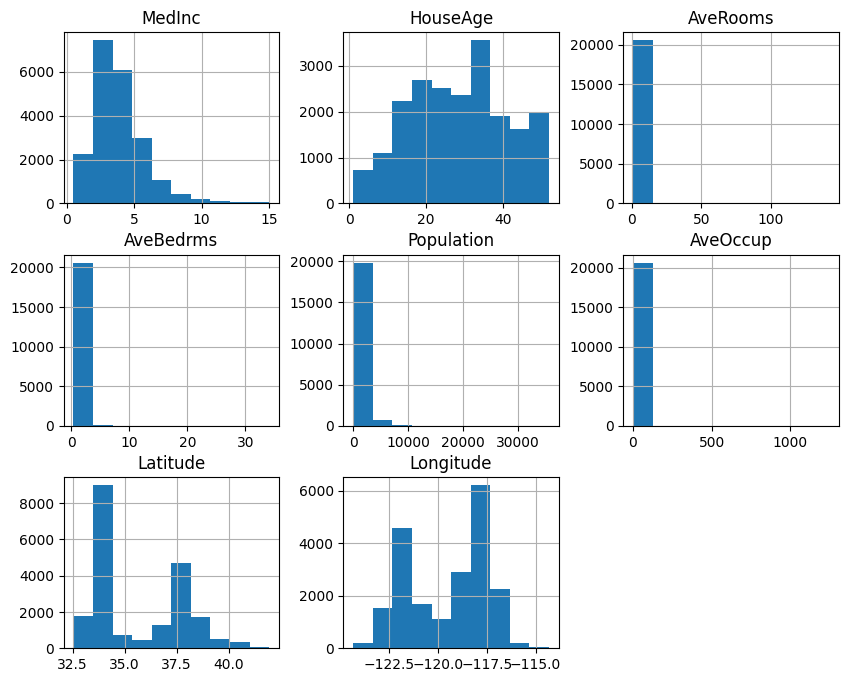

In [51]:
import matplotlib.pyplot as plt

X.hist(figsize=(10, 8))

plt.title("Distribucion de las variables")
plt.show()


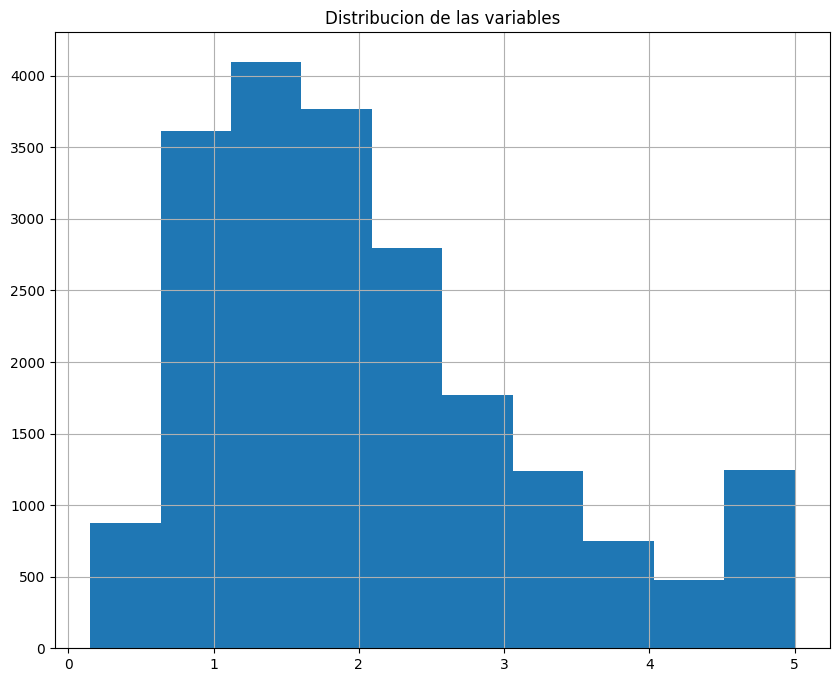

In [56]:
import matplotlib.pyplot as plt

y.hist(figsize=(10, 8))

plt.title("Distribucion de las variables")
plt.show()


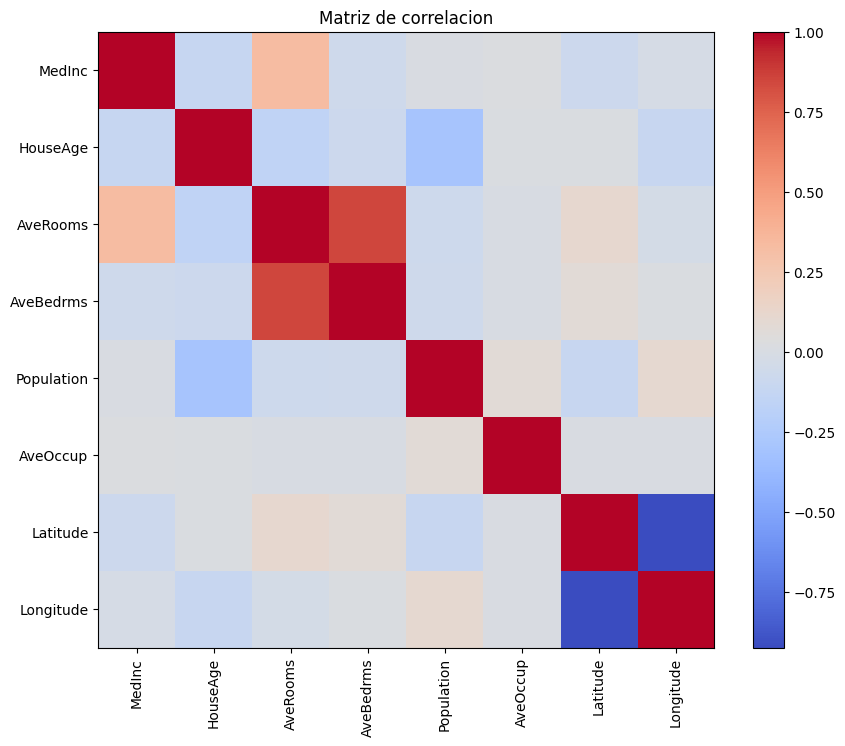

In [53]:
# Correlacion entre variables sin seaborn
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()


plt.title("Matriz de correlacion")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

In [54]:
#Correlacion con el label

df_total = X.copy()
df_total["Value"] = y

corr_with_label = df_total.corr()["Value"].sort_values(ascending=False)

print(corr_with_label)

Value         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Value, dtype: float64


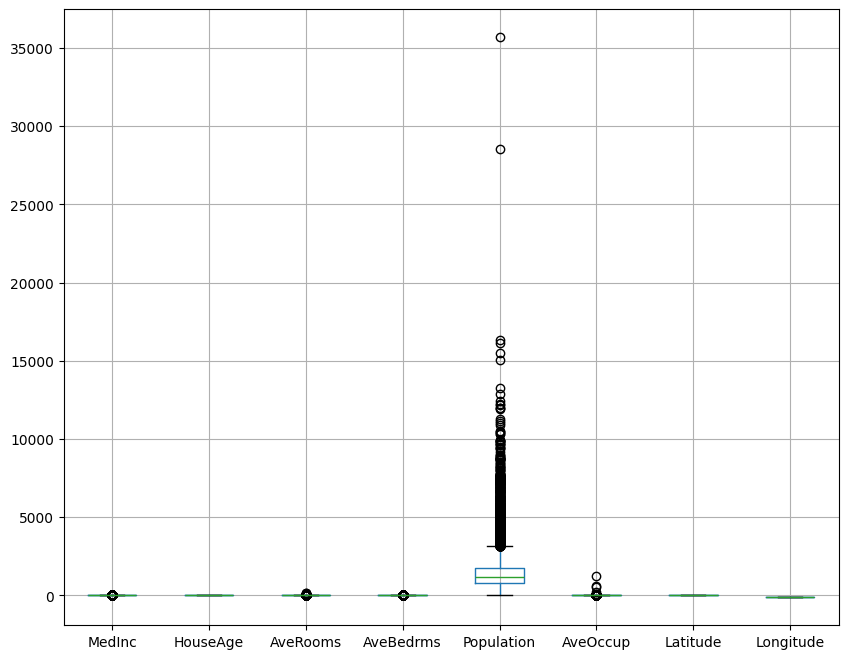

In [55]:
# Deteccion de outliers con boxplot sin seaborn
plt.figure(figsize=(10, 8))

X.boxplot()
plt.show()





---